# Part 1: Dataset with coefficients

In [36]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

In [37]:
df = pd.read_csv('~/graduate-paper-code/spe1/csv_output.csv', sep=',')
df = df[df['well_type'] == 'PROD'].reset_index(drop=True)

df = df[['N_w', 'N_o', 'coef_water', 'oil_prod']].drop_duplicates()


In [38]:
df

,N_w,N_o,coef_water,oil_prod
0,1.477224,3.015671,0.54,44115.5
15,1.477224,2.017118,0.82,44654.9
30,1.477224,4.874770,0.35,43428.7
45,1.477224,4.342614,0.30,43656.3
60,1.477224,4.959825,0.93,43401.7
...,...,...,...,...
37410,4.914668,4.779160,0.66,43514.9
37425,4.914668,4.528723,0.90,43634.1
37440,4.914668,3.598538,0.68,44037.2
37455,4.914668,2.742919,0.41,44314.6


In [39]:
# df = df[(df['N_w'] >= 1) & (df['N_w'] <= 3.5) & (df['N_o'] >= 1) & (df['N_o'] <= 3.5)]

In [40]:
df.describe()

,N_w,N_o,coef_water,oil_prod
count,2499.000000,2499.000000,2499.000000,2499.000000
mean,3.042403,2.900021,0.606583,44302.739176
std,1.210461,1.205712,0.228218,556.126427
min,0.888680,0.800598,0.200000,43324.400000
25%,2.268840,1.867279,0.420000,43859.400000
50%,3.190885,2.946184,0.610000,44194.200000
75%,4.089036,3.937792,0.800000,44756.950000
max,4.966482,4.997579,1.000000,45397.900000


### Simple linear regression and random forest

In [41]:
X = df[['N_o', 'N_w', 'coef_water']]
y = df['oil_prod']

print('shape X - ', X.shape)
print('shape Y - ', y.shape)

# devide train/test 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('X_train.shape: ', X_train.shape)
print('X_train.shape: ', X_train.shape)
print('X_test.shape', X_test.shape)

# linear regression
print('LinearRegression() part')
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)


shape X -  (2499, 3)
shape Y -  (2499,)
X_train.shape:  (1999, 3)
X_train.shape:  (1999, 3)
X_test.shape (500, 3)
LinearRegression() part


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [42]:
y_pred_linear = linear_model.predict(X_test)

mae_linear = mean_absolute_error(y_test, y_pred_linear)
mse_linear = mean_squared_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mse_linear) 
r2_linear = r2_score(y_test, y_pred_linear)


print('linear reg results:')
print('linear model coeffs: ', linear_model.coef_)
print('MAE: ', mae_linear)
print('MSE: ',mse_linear)
print('RMSE: ', rmse_linear)
print('R^2: ', r2_linear)

# RandomForestRegressor
print('RandomForestRegressor')

rf = RandomForestRegressor(random_state=42, n_jobs=-1)

param_dist = {
    'n_estimators': [100, 300, 500, 800],
    'max_depth': [None, 5, 10, 15, 20, 30],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': [1, 2, 3, 'sqrt', None],
    'bootstrap': [True, False],
}
search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=40,
    cv=5,
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=-1,
    verbose=1
)
search.fit(X_train, y_train)

print('best params:', search.best_params_)
# best params: {'n_estimators': 500, 'min_samples_split': 20, 'min_samples_leaf': 8, 'max_features': None, 'max_depth': None, 'bootstrap': True}
# best params: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 8, 'max_features': None, 'max_depth': 30, 'bootstrap': True}
print('best CV score:', -search.best_score_)

random_forest_model = search.best_estimator_


random_forest_model.fit(X_train, y_train)
y_pred_rf = random_forest_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print('random forest results:')
print('MAE: ', mean_absolute_error(y_test, y_pred_rf))
print('MSE: ',mean_squared_error(y_test, y_pred_rf))
print('RMSE: ', np.sqrt(mse_rf))
print('R^2: ', r2_score(y_test, y_pred_rf))

linear reg results:
linear model coeffs:  [-457.39738575   15.58507077    0.47628929]
MAE:  53.80522979970511
MSE:  4170.5041522599295
RMSE:  64.57944063136448
R^2:  0.9868740461313025
RandomForestRegressor
Fitting 5 folds for each of 40 candidates, totalling 200 fits
best params: {'n_estimators': 800, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': None, 'max_depth': 10, 'bootstrap': True}
best CV score: 739.7698992655687
random forest results:
MAE:  17.50797652048913
MSE:  927.1644618793758
RMSE:  30.44937539391204
R^2:  0.9970819072440607


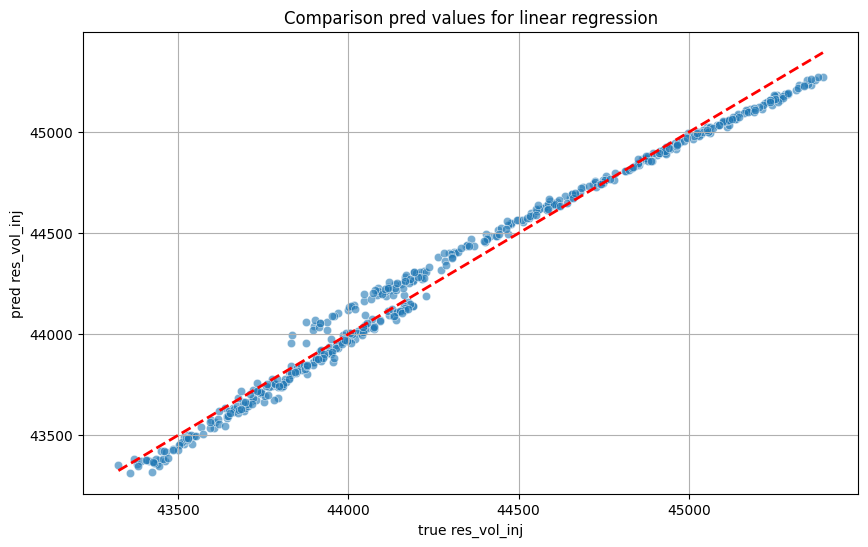

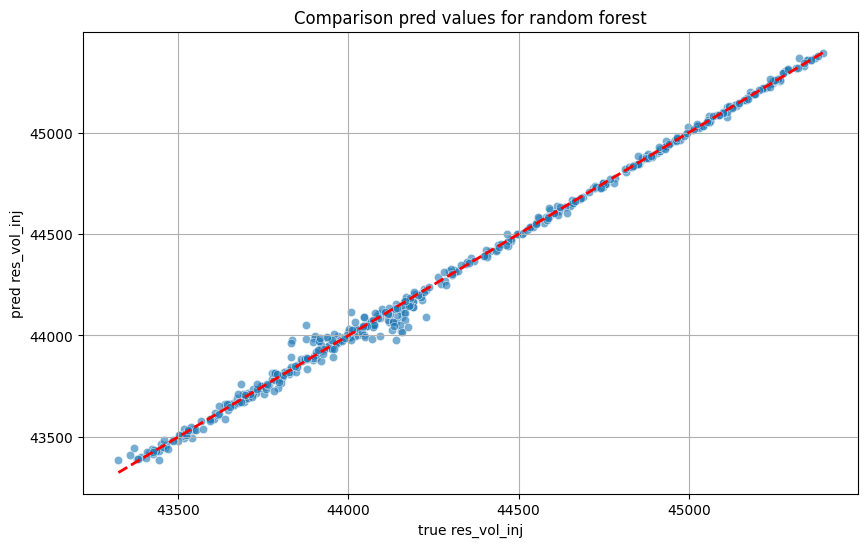

predict some values
new data: 
   N_o   N_w  coef_water
0    5  4.05      0.0001
1    3  8.00      0.0100
2    1  2.00      0.0010
predicted res_vol_inj:
[43420.84062144 44172.60275991 45245.36311143]
Features importance
N_o           0.998008
N_w           0.001665
coef_water    0.000328
dtype: float64


In [43]:
# visualizing part for linear regression
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_linear, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('true res_vol_inj')
plt.ylabel('pred res_vol_inj')
plt.title('Comparison pred values for linear regression')
plt.grid(True)
plt.show()

# visualizing part for random forest
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_rf, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('true res_vol_inj')
plt.ylabel('pred res_vol_inj')
plt.title('Comparison pred values for random forest')
plt.grid(True)
plt.show()

print('predict some values')
new_data_for_prediction = pd.DataFrame({
    'N_o': [5, 3, 1],
    'N_w': [4.05, 8, 2],
    'coef_water': [0.0001, 0.01, 0.001]
})
predicted_res_vol_inj = random_forest_model.predict(new_data_for_prediction)

print(f'new data: \n{new_data_for_prediction}')
print(f'predicted res_vol_inj:\n{predicted_res_vol_inj}')

print('Features importance')
feature_importances = pd.Series(random_forest_model.feature_importances_, index=X.columns)
print(feature_importances.sort_values(ascending=False))


In [44]:
models = {
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.001),
    'ElasticNet': ElasticNet(alpha=0.001, l1_ratio=0.5)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    print(name)
    print('MAE:', mean_absolute_error(y_test, pred))
    print('MSE:', mean_squared_error(y_test, pred))
    print('RMSE:', np.sqrt(mean_squared_error(y_test, pred)))
    print('R2:', r2_score(y_test, pred))
    print()

Ridge
MAE: 53.787082366176215
MSE: 4171.519415671261
RMSE: 64.58730073064876
R2: 0.986870850762058

Lasso
MAE: 53.80497126379541
MSE: 4170.464879200519
RMSE: 64.579136562829
R2: 0.9868741697365903

ElasticNet
MAE: 53.78696333207458
MSE: 4171.4996610118515
RMSE: 64.58714780056363
R2: 0.9868709129364952



so, the best model is Random Forest

#### Collect some statistic

In [45]:
test_df = X_test

test_df['oil_prod_pred'] = y_pred_rf
test_df['oil_prod'] = y_test
test_df

,N_o,N_w,coef_water,oil_prod_pred,oil_prod
34785,1.969138,3.992887,0.92,44725.764087,44719.1
27975,4.706508,3.937812,0.47,43539.092754,43541.3
13530,3.586656,4.362706,0.83,44031.334474,44036.4
33600,0.824531,1.838800,0.98,45357.315516,45359.2
19275,2.647381,2.490131,0.91,44321.804268,44309.9
...,...,...,...,...,...
30810,3.926045,3.725436,0.30,43884.689225,43877.5
27900,2.061509,3.937812,0.29,44662.208495,44664.5
27930,1.075158,3.937812,0.42,45223.468054,45237.9
17265,2.639659,4.094857,0.26,44356.560799,44354.7


                                                        value
count                                                     500
mean                                                -1.359007
variance                                           927.171904
std(sigma)                                          30.449498
median                                              -1.149687
mode        [-159.608012246601, -139.16885123909742, -134....


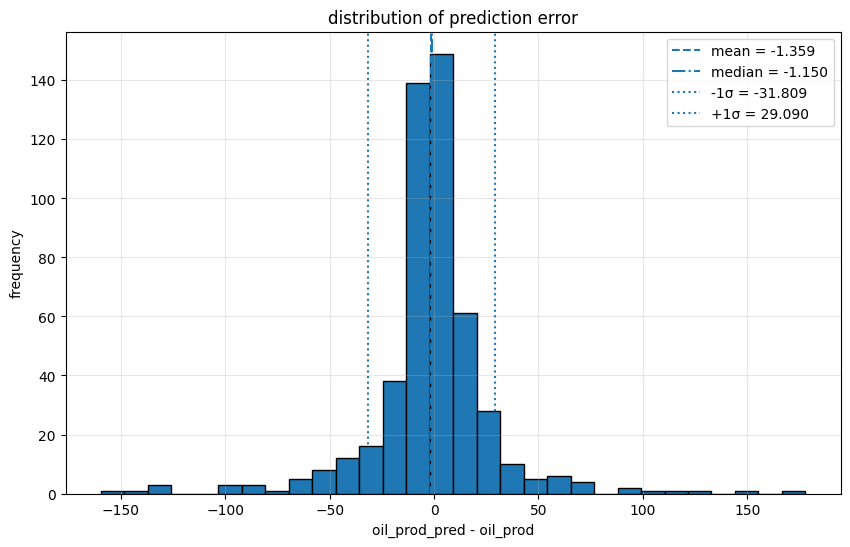

In [46]:
test_df['diff'] = test_df['oil_prod_pred'] - test_df['oil_prod']

diff = test_df['diff']

stats = {
    'count': diff.count(),
    'mean': diff.mean(),
    'variance': diff.var(),
    'std(sigma)': diff.std(),
    'median': diff.median(),
    'mode': diff.mode().tolist()
}

stats_df = pd.DataFrame.from_dict(stats, orient='index', columns=['value'])
print(stats_df)

plt.figure(figsize=(10, 6))
plt.hist(diff, bins=30, edgecolor='black')
plt.axvline(diff.mean(), linestyle='--', label=f'mean = {diff.mean():.3f}')
plt.axvline(diff.median(), linestyle='-.', label=f'median = {diff.median():.3f}')
plt.axvline(diff.mean() - diff.std(), linestyle=':', label=f'-1σ = {diff.mean() - diff.std():.3f}')
plt.axvline(diff.mean() + diff.std(), linestyle=':', label=f'+1σ = {diff.mean() + diff.std():.3f}')
plt.xlabel('oil_prod_pred - oil_prod')
plt.ylabel('frequency')
plt.title('distribution of prediction error')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Sobol coefficient

/tmp/ipykernel_5392/1105106779.py:14: DeprecationWarning: `salib.sample.saltelli` will be removed in SALib 1.5.1 Please use `salib.sample.sobol`
  param_values = saltelli.sample(problem, 1024, calc_second_order=True)


      feature        S1        ST   S1_conf   ST_conf
0         N_o  0.999036  0.999963  0.082288  0.067915
1         N_w  0.001044  0.001620  0.003050  0.000241
2  coef_water -0.000008  0.000049  0.000589  0.000012


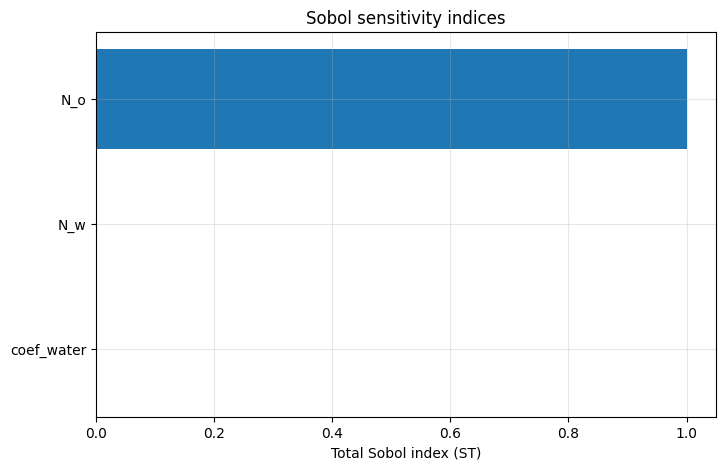

Pairwise interactions S2:
            N_o       N_w  coef_water
N_o         NaN  0.000749   -0.000051
N_w         NaN       NaN   -0.000121
coef_water  NaN       NaN         NaN


In [47]:
from SALib.sample import saltelli
from SALib.analyze import sobol

problem = {
    'num_vars': 3,
    'names': ['N_o', 'N_w', 'coef_water'],
    'bounds': [
        [df['N_o'].min(), df['N_o'].max()],
        [df['N_w'].min(), df['N_w'].max()],
        [df['coef_water'].min(), df['coef_water'].max()],
    ]
}

param_values = saltelli.sample(problem, 1024, calc_second_order=True)

X_sobol = pd.DataFrame(param_values, columns=problem['names'])
Y = random_forest_model.predict(X_sobol)

Si = sobol.analyze(problem, Y, calc_second_order=True)

sobol_df = pd.DataFrame({
    'feature': problem['names'],
    'S1': Si['S1'],
    'ST': Si['ST'],
    'S1_conf': Si['S1_conf'],
    'ST_conf': Si['ST_conf'],
})

print(sobol_df.sort_values('ST', ascending=False))

sobol_df_sorted = sobol_df.sort_values('ST', ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(sobol_df_sorted['feature'], sobol_df_sorted['ST'])
plt.xlabel('Total Sobol index (ST)')
plt.title('Sobol sensitivity indices')
plt.grid(True, alpha=0.3)
plt.show()

print('Pairwise interactions S2:')
print(pd.DataFrame(Si['S2'], index=problem['names'], columns=problem['names']))

### Monte-Carlo method

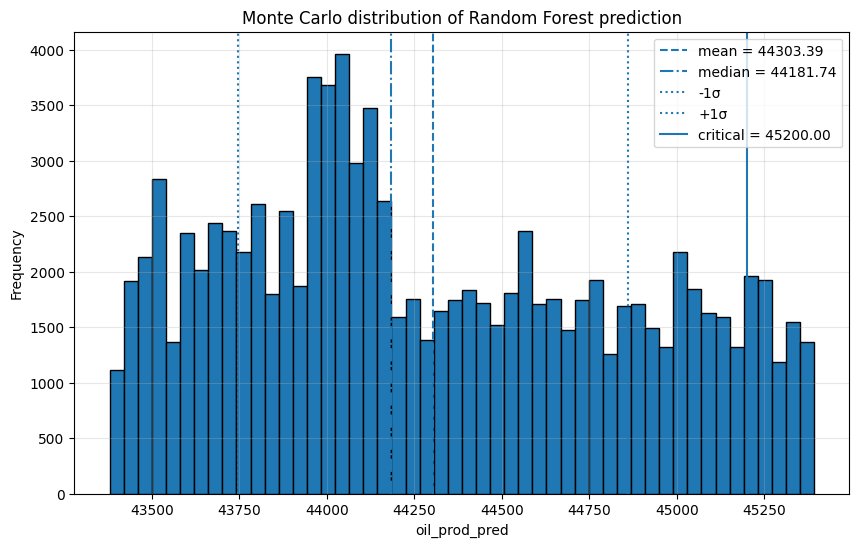

mean                       44303.393596
variance                  309991.039553
std                          556.768390
median                     44181.737013
mode_approx_bin_center              NaN
q01                        43413.227347
q05                        43496.831929
q25                        43859.891388
q75                        44765.158718
q95                        45251.951186
q99                        45358.446962
min                        43378.835817
max                        45392.437372
P(y < 45200)                   0.925440
Name: mc_stats, dtype: float64


In [48]:
def mc_risk_analysis_rf(model, df, n_mc=100_000, critical_value=None, random_state=42):
    rng = np.random.default_rng(random_state)

    X_mc = pd.DataFrame({
        "N_o": rng.choice(df["N_o"].values, size=n_mc, replace=True),
        "N_w": rng.choice(df["N_w"].values, size=n_mc, replace=True),
        "coef_water": rng.choice(df["coef_water"].values, size=n_mc, replace=True),
    })

    y_mc = model.predict(X_mc)

    stats = {
        "mean": np.mean(y_mc),
        "variance": np.var(y_mc, ddof=1),
        "std": np.std(y_mc, ddof=1),
        "median": np.median(y_mc),
        "mode_approx_bin_center": None,
        "q01": np.quantile(y_mc, 0.01),
        "q05": np.quantile(y_mc, 0.05),
        "q25": np.quantile(y_mc, 0.25),
        "q75": np.quantile(y_mc, 0.75),
        "q95": np.quantile(y_mc, 0.95),
        "q99": np.quantile(y_mc, 0.99),
        "min": np.min(y_mc),
        "max": np.max(y_mc),
    }

    if critical_value is not None:
        stats[f"P(y < {critical_value})"] = np.mean(y_mc < critical_value)

    stats = pd.Series(stats, name="mc_stats")

    plt.figure(figsize=(10, 6))
    plt.hist(y_mc, bins=50, edgecolor="black")
    plt.axvline(np.mean(y_mc), linestyle="--", label=f"mean = {np.mean(y_mc):.2f}")
    plt.axvline(np.median(y_mc), linestyle="-.", label=f"median = {np.median(y_mc):.2f}")
    plt.axvline(np.mean(y_mc) - np.std(y_mc, ddof=1), linestyle=":", label="-1σ")
    plt.axvline(np.mean(y_mc) + np.std(y_mc, ddof=1), linestyle=":", label="+1σ")
    if critical_value is not None:
        plt.axvline(critical_value, linestyle="-", label=f"critical = {critical_value:.2f}")
    plt.xlabel("oil_prod_pred")
    plt.ylabel("Frequency")
    plt.title("Monte Carlo distribution of Random Forest prediction")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    return X_mc, y_mc, stats

X_mc, y_mc, stats = mc_risk_analysis_rf(
    model=random_forest_model,
    df=df,
    n_mc=100_000,
    critical_value=45200,
    random_state=42
)

print(stats)

## PCE

In [49]:
from pclearn import OrthogonalPolynomialsFeatures
from sklearn.linear_model import ElasticNetCV
from sklearn.pipeline import Pipeline

import time

In [50]:
X = df[['N_w', 'N_o', ]].values
y = df['oil_prod'].values
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [51]:
tol_eps = 1.0e-6  # tolerance
n_cv_folds = 5
alphas = np.logspace(-5, 1, 5)
l1_ratio = np.linspace(0.05, 0.95, 10)
n_max_iter = 500

fitting_method = ElasticNetCV(l1_ratio=l1_ratio, alphas=alphas,
                              max_iter=n_max_iter, tol=tol_eps, cv=n_cv_folds,
                              fit_intercept=False, selection='random')


poly_degree = 8
n_samples_train, n_features = X_train.shape
poly_type = ['legendre'] * n_features
dlist = []
reduction = False
truncated_dim = 20
single_iter_dim = 10
niter = 500
nrand = 50

orthopoly = OrthogonalPolynomialsFeatures(
    degree=poly_degree, dlist=dlist, poly_type=poly_type,
    reduction=reduction, basis_dim=truncated_dim,
    single_iter_dim=single_iter_dim, niter=niter, nrand=nrand,
    clf=fitting_method)


In [52]:
regression_pipeline = Pipeline(steps=[
    ('orthopoly', orthopoly),
    ('fitting_method', fitting_method)])

t_start = time.time()
regression_pipeline.fit(X_train, y_train)
print('Linear problem (with PCE basis) has been solved in {:6f} seconds'.format(time.time() - t_start))

n_output_features: 45


/home/dmitrysavinskikh/graduate-paper-code/venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.248e+11, tolerance: 3.139e+06
  model = cd_fast.enet_coordinate_descent_gram(
/home/dmitrysavinskikh/graduate-paper-code/venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.626e+10, tolerance: 3.139e+06
  model = cd_fast.enet_coordinate_descent_gram(
/home/dmitrysavinskikh/graduate-paper-code/venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of ite

Linear problem (with PCE basis) has been solved in 0.400600 seconds


/home/dmitrysavinskikh/graduate-paper-code/venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.289e+10, tolerance: 3.140e+06
  model = cd_fast.enet_coordinate_descent_gram(
/home/dmitrysavinskikh/graduate-paper-code/venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.828e+09, tolerance: 3.140e+06
  model = cd_fast.enet_coordinate_descent_gram(
/home/dmitrysavinskikh/graduate-paper-code/venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of ite

Prediction over the test data in 0.412494 seconds
MSE test 143389.08063919953


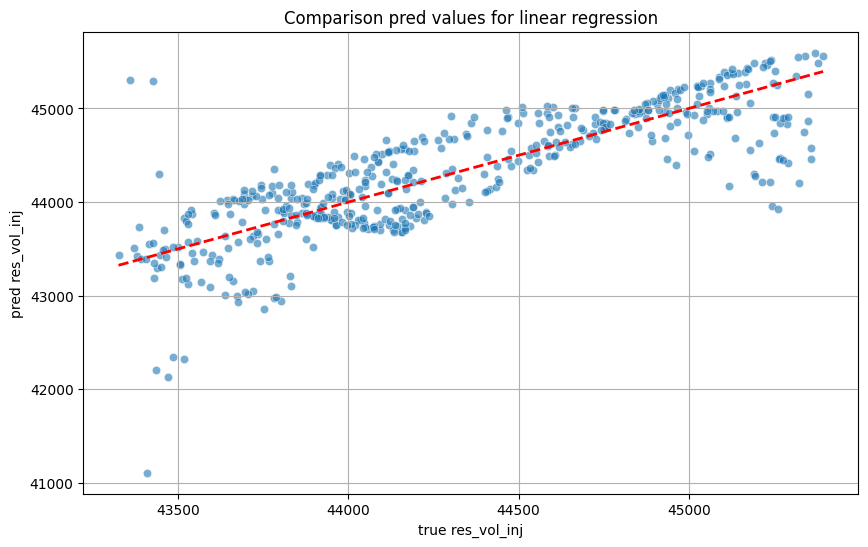

In [53]:
y_test_pred = regression_pipeline.predict(X_test)
print('Prediction over the test data in {:6f} seconds'.format(time.time() - t_start))
mse_test = mean_squared_error(y_test, y_test_pred)
print('MSE test {}'.format(mse_test))

# visualizing part for linear regression
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_test_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('true res_vol_inj')
plt.ylabel('pred res_vol_inj')
plt.title('Comparison pred values for linear regression')
plt.grid(True)
plt.show()

# Part 2: Dataset with whole SWOF matrix

In [59]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

In [60]:
df = pd.read_csv('~/graduate-paper-code/spe1/csv_output.csv', sep=',')
df = df[df['well_type'] == 'PROD'].reset_index(drop=True)

df = df[['iteration', 'water_relative_permeability', 'oil_relative_permeability', 'oil_prod']]
df['oil_relative_permeability'] = df['oil_relative_permeability'].round(2)

In [61]:
df

,iteration,water_relative_permeability,oil_relative_permeability,oil_prod
0,0,0.00,0.68,44115.5
1,0,0.04,0.55,44115.5
2,0,0.07,0.44,44115.5
3,0,0.09,0.34,44115.5
4,0,0.12,0.26,44115.5
...,...,...,...,...
37480,2499,0.19,0.00,43409.5
37481,2499,0.28,0.00,43409.5
37482,2499,0.40,0.00,43409.5
37483,2499,0.60,0.00,43409.5


In [62]:
X_rows = []
y_rows = []

for iteration_id, group in df.groupby("iteration"):
    group = group.sort_index()
    if len(group) != 15:
        continue
    
    features = []
    features.extend(group["water_relative_permeability"].tolist())
    features.extend(group["oil_relative_permeability"].tolist())
    X_rows.append(features)
    y_rows.append(group["oil_prod"].iloc[0])

X = pd.DataFrame(X_rows)
y = pd.Series(y_rows, name="oil_prod")


X.columns = (
    [f"water_rel_perm_{i+1}" for i in range(15)] +
    [f"oil_rel_perm_{i+1}" for i in range(15)])
X = X.drop(columns='oil_rel_perm_15') # this column always is 0
X = X.drop(columns='water_rel_perm_1') # this column always is 0
print(X.shape, y.shape)
df = X.join(y)

(2499, 28) (2499,)


In [63]:
pd.set_option('display.max_columns', None)
X

,water_rel_perm_2,water_rel_perm_3,water_rel_perm_4,water_rel_perm_5,water_rel_perm_6,water_rel_perm_7,water_rel_perm_8,water_rel_perm_9,water_rel_perm_10,water_rel_perm_11,water_rel_perm_12,water_rel_perm_13,water_rel_perm_14,water_rel_perm_15,oil_rel_perm_1,oil_rel_perm_2,oil_rel_perm_3,oil_rel_perm_4,oil_rel_perm_5,oil_rel_perm_6,oil_rel_perm_7,oil_rel_perm_8,oil_rel_perm_9,oil_rel_perm_10,oil_rel_perm_11,oil_rel_perm_12,oil_rel_perm_13,oil_rel_perm_14
0,0.04,0.07,0.09,0.12,0.15,0.18,0.22,0.25,0.29,0.33,0.37,0.42,0.47,0.54,0.68,0.55,0.44,0.34,0.26,0.19,0.14,0.10,0.06,0.04,0.02,0.01,0.00,0.00
1,0.07,0.10,0.14,0.18,0.23,0.28,0.33,0.39,0.44,0.50,0.57,0.63,0.71,0.82,0.77,0.67,0.57,0.49,0.41,0.33,0.27,0.21,0.16,0.11,0.08,0.05,0.02,0.01
2,0.03,0.04,0.06,0.08,0.10,0.12,0.14,0.16,0.19,0.22,0.24,0.27,0.30,0.35,0.54,0.38,0.26,0.18,0.11,0.07,0.04,0.02,0.01,0.01,0.00,0.00,0.00,0.00
3,0.02,0.04,0.05,0.07,0.08,0.10,0.12,0.14,0.16,0.18,0.21,0.23,0.26,0.30,0.57,0.42,0.30,0.21,0.14,0.09,0.06,0.03,0.02,0.01,0.00,0.00,0.00,0.00
4,0.07,0.11,0.16,0.21,0.26,0.31,0.37,0.44,0.50,0.57,0.64,0.72,0.81,0.93,0.53,0.37,0.26,0.17,0.11,0.07,0.04,0.02,0.01,0.00,0.00,0.00,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2494,0.00,0.00,0.00,0.00,0.01,0.02,0.03,0.05,0.09,0.13,0.19,0.28,0.42,0.66,0.54,0.39,0.27,0.18,0.12,0.07,0.04,0.02,0.01,0.01,0.00,0.00,0.00,0.00
2495,0.00,0.00,0.00,0.01,0.01,0.02,0.04,0.07,0.12,0.18,0.27,0.38,0.57,0.90,0.56,0.41,0.29,0.20,0.13,0.08,0.05,0.03,0.02,0.01,0.00,0.00,0.00,0.00
2496,0.00,0.00,0.00,0.00,0.01,0.02,0.03,0.06,0.09,0.14,0.20,0.29,0.43,0.68,0.63,0.49,0.37,0.28,0.20,0.14,0.10,0.06,0.04,0.02,0.01,0.00,0.00,0.00
2497,0.00,0.00,0.00,0.00,0.01,0.01,0.02,0.03,0.05,0.08,0.12,0.17,0.26,0.41,0.70,0.58,0.47,0.38,0.29,0.22,0.17,0.12,0.08,0.05,0.03,0.02,0.01,0.00


In [64]:
# devide train/test 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('X_train.shape: ', X_train.shape)
print('X_train.shape: ', X_train.shape)
print('X_test.shape', X_test.shape)

# linear regression
print('LinearRegression() part')
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# RandomForestRegressor
print('RandomForestRegressor')

rf = RandomForestRegressor(random_state=42, n_jobs=-1)

param_dist = {
    'n_estimators': [100, 300, 500, 800],
    'max_depth': [None, 5, 10, 15, 20, 30],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': [1, 2, 3, 'sqrt', None],
    'bootstrap': [True, False],
}
search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=40,
    cv=5,
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=-1,
    verbose=1
)
search.fit(X_train, y_train)

print('best params:', search.best_params_)
# best params: {'n_estimators': 500, 'min_samples_split': 20, 'min_samples_leaf': 8, 'max_features': None, 'max_depth': None, 'bootstrap': True}
# best params: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 8, 'max_features': None, 'max_depth': 30, 'bootstrap': True}
print('best CV score:', -search.best_score_)

random_forest_model_29f = search.best_estimator_


random_forest_model_29f.fit(X_train, y_train)

X_train.shape:  (1999, 28)
X_train.shape:  (1999, 28)
X_test.shape (500, 28)
LinearRegression() part
RandomForestRegressor
Fitting 5 folds for each of 40 candidates, totalling 200 fits
best params: {'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 3, 'max_depth': 10, 'bootstrap': False}
best CV score: 674.4435010987219


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",3
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

In [65]:
y_pred_linear = linear_model.predict(X_test)

mae_linear = mean_absolute_error(y_test, y_pred_linear)
mse_linear = mean_squared_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mse_linear) 
r2_linear = r2_score(y_test, y_pred_linear)


print('linear reg results:')
print('linear model coeffs: ', linear_model.coef_)
print('MAE: ', mae_linear)
print('MSE: ',mse_linear)
print('RMSE: ', rmse_linear)
print('R^2: ', r2_linear)


y_pred_rf = random_forest_model_29f.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print('random forest results:')
print('MAE: ', mean_absolute_error(y_test, y_pred_rf))
print('MSE: ',mean_squared_error(y_test, y_pred_rf))
print('RMSE: ', np.sqrt(mse_rf))
print('R^2: ', r2_score(y_test, y_pred_rf))


linear reg results:
linear model coeffs:  [ -951.0224541    908.69803215   776.1794963    502.68316007
    10.87755195  -588.84175454   174.75231629   -10.23197705
 -1124.5786953   -324.87048571   372.17726259   594.37001144
    27.08536891  -124.5188169   2343.3604676   2117.08136302
   350.3642465    363.57117719  -493.92627737 -1161.11143349
  -413.76466742  1186.23849162   903.30321391  -753.82098
  2283.09209179 -2188.58783015  -672.44193682   553.09693168]
MAE:  31.016288518899614
MSE:  1683.6784852521173
RMSE:  41.03265145286272
R^2:  0.9947009077751038
random forest results:
MAE:  17.329322883524846
MSE:  819.3887365218769
RMSE:  28.62496701346356
R^2:  0.9974211130445012


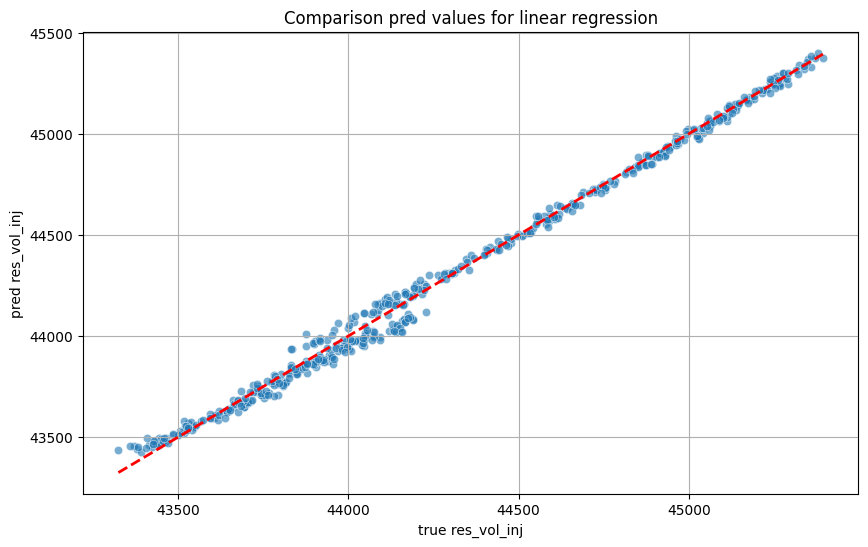

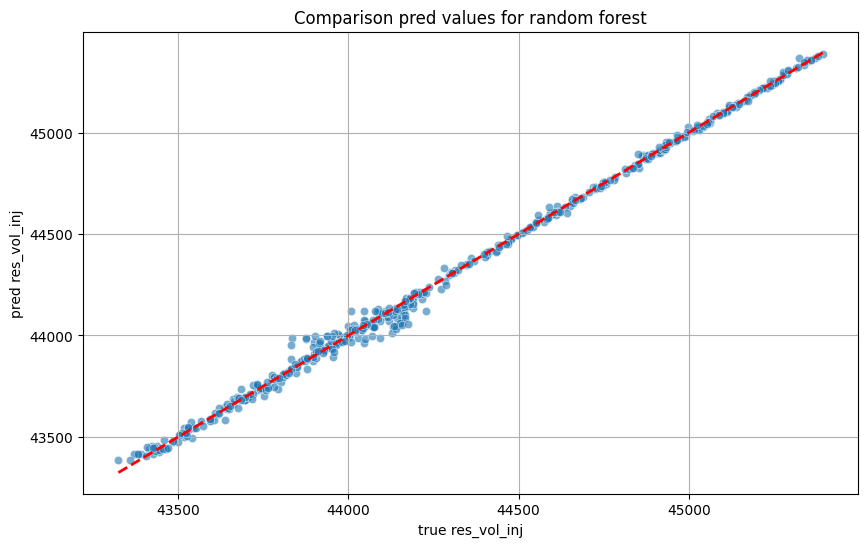

In [66]:
# visualizing part for linear regression
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_linear, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('true res_vol_inj')
plt.ylabel('pred res_vol_inj')
plt.title('Comparison pred values for linear regression')
plt.grid(True)
plt.show()

# visualizing part for random forest
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_rf, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('true res_vol_inj')
plt.ylabel('pred res_vol_inj')
plt.title('Comparison pred values for random forest')
plt.grid(True)
plt.show()


/tmp/ipykernel_5392/1283907521.py:41: DeprecationWarning: `salib.sample.saltelli` will be removed in SALib 1.5.1 Please use `salib.sample.sobol`
  param_values = saltelli.sample(problem, 1024, calc_second_order=True)


              feature        S1        ST   S1_conf       ST_conf
15     oil_rel_perm_2  0.189963  0.190423  0.034439  1.712085e-02
14     oil_rel_perm_1  0.136355  0.137121  0.032469  1.248596e-02
24    oil_rel_perm_11  0.125310  0.123151  0.027358  1.193726e-02
8   water_rel_perm_10  0.102426  0.100409  0.026454  1.014727e-02
19     oil_rel_perm_6  0.082588  0.082720  0.025403  8.121631e-03
25    oil_rel_perm_12  0.078577  0.078560  0.022895  7.992891e-03
21     oil_rel_perm_8  0.069442  0.069353  0.025331  7.009323e-03
11  water_rel_perm_13  0.038675  0.038177  0.016391  3.738700e-03
22     oil_rel_perm_9  0.032905  0.032852  0.017749  2.859141e-03
23    oil_rel_perm_10  0.020645  0.018269  0.012323  1.570100e-03
5    water_rel_perm_7  0.017733  0.016438  0.010417  1.431652e-03
18     oil_rel_perm_5  0.016133  0.015479  0.010459  1.310162e-03
10  water_rel_perm_12  0.014063  0.013815  0.010284  1.366345e-03
2    water_rel_perm_4  0.012759  0.012703  0.009951  1.288921e-03
1    water

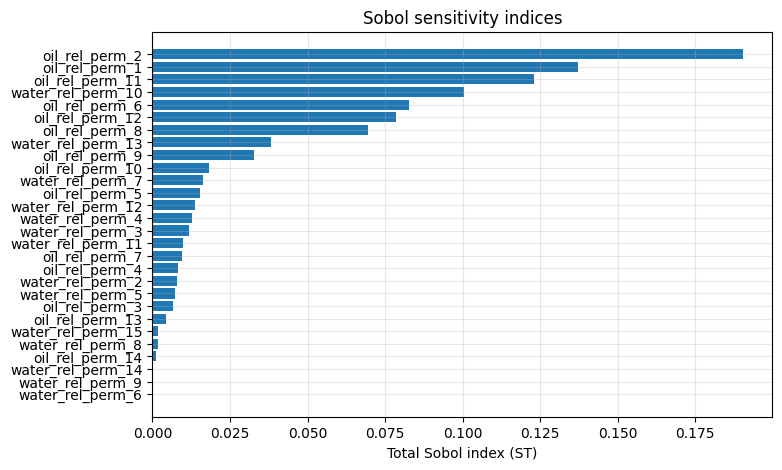

              feature        S1        ST   S1_conf   ST_conf
18     oil_rel_perm_5  0.158826  0.159277  0.034289  0.015661
17     oil_rel_perm_4  0.129267  0.139102  0.027966  0.012270
15     oil_rel_perm_2  0.118288  0.121167  0.027594  0.011378
14     oil_rel_perm_1  0.099004  0.103785  0.025369  0.009984
22     oil_rel_perm_9  0.087856  0.096953  0.027138  0.009770
16     oil_rel_perm_3  0.073460  0.073903  0.023892  0.006372
21     oil_rel_perm_8  0.069498  0.073543  0.022708  0.007694
19     oil_rel_perm_6  0.060645  0.064718  0.022843  0.006058
23    oil_rel_perm_10  0.055987  0.060724  0.020139  0.007391
20     oil_rel_perm_7  0.049498  0.051041  0.018213  0.005277
25    oil_rel_perm_12  0.036420  0.035081  0.018398  0.004476
24    oil_rel_perm_11  0.010427  0.012441  0.008694  0.001512
26    oil_rel_perm_13  0.009540  0.009807  0.009774  0.001394
27    oil_rel_perm_14  0.004821  0.005927  0.007431  0.000834
3    water_rel_perm_5  0.000948  0.000736  0.002286  0.000149
7    wat

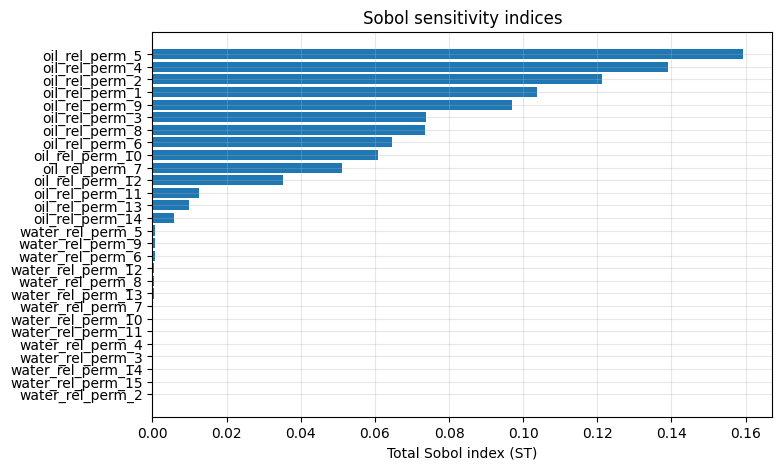

In [67]:
from SALib.sample import saltelli
from SALib.analyze import sobol
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

features = [
    'water_rel_perm_2','water_rel_perm_3','water_rel_perm_4','water_rel_perm_5',
    'water_rel_perm_6','water_rel_perm_7','water_rel_perm_8','water_rel_perm_9','water_rel_perm_10',
    'water_rel_perm_11','water_rel_perm_12','water_rel_perm_13','water_rel_perm_14','water_rel_perm_15',
    'oil_rel_perm_1','oil_rel_perm_2','oil_rel_perm_3','oil_rel_perm_4','oil_rel_perm_5',
    'oil_rel_perm_6','oil_rel_perm_7','oil_rel_perm_8','oil_rel_perm_9','oil_rel_perm_10',
    'oil_rel_perm_11','oil_rel_perm_12','oil_rel_perm_13','oil_rel_perm_14',
]

bounds = []
valid_features = []

for col in features:
    s = pd.to_numeric(df[col], errors='coerce')
    mn = s.min()
    mx = s.max()

    if pd.isna(mn) or pd.isna(mx):
        print(f'Пропущен {col}: NaN в границах')
        continue

    if mn == mx:
        print(f'Пропущен {col}: min == max == {mn}')
        continue

    bounds.append([mn, mx])
    valid_features.append(col)

problem = {
    'num_vars': len(valid_features),
    'names': valid_features,
    'bounds': bounds
}

param_values = saltelli.sample(problem, 1024, calc_second_order=True)

X_sobol = pd.DataFrame(param_values, columns=problem['names'])
Y = linear_model.predict(X_sobol)

Si = sobol.analyze(problem, Y, calc_second_order=True)

sobol_df = pd.DataFrame({
    'feature': problem['names'],
    'S1': Si['S1'],
    'ST': Si['ST'],
    'S1_conf': Si['S1_conf'],
    'ST_conf': Si['ST_conf'],
})

print(sobol_df.sort_values('ST', ascending=False))

sobol_df_sorted = sobol_df.sort_values('ST', ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(sobol_df_sorted['feature'], sobol_df_sorted['ST'])
plt.xlabel('Total Sobol index (ST)')
plt.title('Sobol sensitivity indices')
plt.grid(True, alpha=0.3)
plt.show()

# print('Pairwise interactions S2:')
# print(pd.DataFrame(Si['S2'], index=problem['names'], columns=problem['names']))


# random forest
X_sobol = pd.DataFrame(param_values, columns=problem['names'])
Y = random_forest_model_29f.predict(X_sobol)

Si = sobol.analyze(problem, Y, calc_second_order=True)

sobol_df = pd.DataFrame({
    'feature': problem['names'],
    'S1': Si['S1'],
    'ST': Si['ST'],
    'S1_conf': Si['S1_conf'],
    'ST_conf': Si['ST_conf'],
})

print(sobol_df.sort_values('ST', ascending=False))

sobol_df_sorted = sobol_df.sort_values('ST', ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(sobol_df_sorted['feature'], sobol_df_sorted['ST'])
plt.xlabel('Total Sobol index (ST)')
plt.title('Sobol sensitivity indices')
plt.grid(True, alpha=0.3)
plt.show()